# Описание выборок, оценки параметров, доверительные интервалы

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv('data/rgr1.csv')
n = len(df)
df.head()

,X1,X2,X3,X4
0,47.73,33.93,50.92,118.81
1,39.01,31.50,204.28,107.52
2,44.94,65.94,67.03,38.81
3,52.82,32.80,34.55,33.95
4,53.82,63.95,25.68,100.77


In [2]:
tab = pd.DataFrame({
    'mean': df.mean(),
    'median': df.median(),
    'var': df.var(ddof=1),
    'sd': df.std(ddof=1),
    'q1': df.quantile(0.25),
    'q3': df.quantile(0.75),
})
tab.round(4)

,mean,median,var,sd,q1,q3
X1,50.5689,50.335,86.7702,9.3151,44.3900,56.5600
X2,49.0995,47.900,167.5754,12.9451,38.2875,59.1750
X3,79.8089,63.350,3318.1661,57.6035,41.1600,98.1825
X4,71.2965,46.760,1398.9431,37.4024,38.7125,112.9400


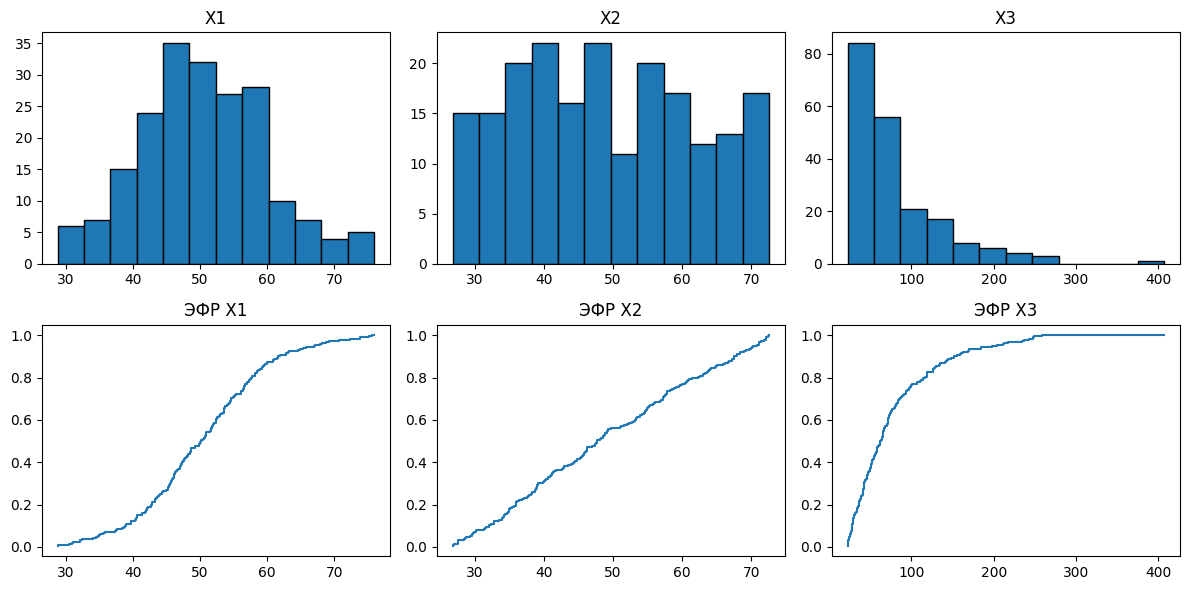

In [3]:
fig, ax = plt.subplots(2, 3, figsize=(12, 6))
for i, c in enumerate(['X1', 'X2', 'X3']):
    v = np.sort(df[c].values)
    ax[0][i].hist(v, bins=12, edgecolor='black')
    ax[0][i].set_title(c)
    ax[1][i].step(v, np.arange(1, n + 1) / n)
    ax[1][i].set_title('ЭФР ' + c)
plt.tight_layout()
plt.show()

X1 колокол, X2 почти прямоугольник, X3 с длинным правым хвостом. Берем нормальное, равномерное и показательное со сдвигом.

In [4]:
x1 = df['X1'].values
x2 = df['X2'].values
x3 = df['X3'].values

print('X1, мм и ммп дают одно и то же:', round(x1.mean(), 4), round(x1.var(), 4))

a_mm = x2.mean() - np.sqrt(3 * x2.var())
b_mm = x2.mean() + np.sqrt(3 * x2.var())
print('X2, мм:', round(a_mm, 4), round(b_mm, 4), ' ммп:', x2.min(), x2.max())

lam_mm = 1 / x3.std()
c_mp = x3.min()
lam_mp = 1 / (x3.mean() - c_mp)
print('X3, мм:', round(lam_mm, 6), round(x3.mean() - 1 / lam_mm, 4), ' ммп:', round(lam_mp, 6), c_mp)

X1, мм и ммп дают одно и то же: 50.5689 86.3364
X2, мм: 26.7341 71.4649  ммп: 26.8 72.57
X3, мм: 0.017404 22.3496  ммп: 0.01744 22.47


In [5]:
# порог берем как среднее плюс сигма
for c in ['X1', 'X2', 'X3']:
    v = df[c].values
    x0 = v.mean() + v.std()
    emp = (v > x0).mean()
    if c == 'X1':
        par = 1 - stats.norm.cdf(x0, v.mean(), v.std())
    elif c == 'X2':
        a = v.mean() - np.sqrt(3 * v.var())
        b = v.mean() + np.sqrt(3 * v.var())
        par = (b - x0) / (b - a)
    else:
        lam = 1 / v.std()
        par = np.exp(-lam * (x0 - (v.mean() - 1 / lam)))
    print(c, 'x0', round(x0, 2), ' эмпирическая', round(emp, 4), ' параметрическая', round(par, 4),
          ' разница', round(abs(emp - par), 4))

X1 x0 59.86  эмпирическая 0.14  параметрическая 0.1587  разница 0.0187
X2 x0 62.01  эмпирическая 0.205  параметрическая 0.2113  разница 0.0063
X3 x0 137.27  эмпирическая 0.135  параметрическая 0.1353  разница 0.0003


In [6]:
cnt, edges = np.histogram(x1, bins=10)
mid = (edges[:-1] + edges[1:]) / 2
mg = (cnt * mid).sum() / n
vg = (cnt * (mid - mg) ** 2).sum() / n

print('среднее: точное', round(x1.mean(), 4), ' по группам', round(mg, 4))
print('дисперсия: точная', round(x1.var(), 4), ' по группам', round(vg, 4))
print('ошибки в процентах', round(abs(mg - x1.mean()) / x1.mean() * 100, 2),
      round(abs(vg - x1.var()) / x1.var() * 100, 2))

среднее: точное 50.5689  по группам 50.499
дисперсия: точная 86.3364  по группам 86.0348
ошибки в процентах 0.14 0.35


In [7]:
z = stats.norm.ppf(0.975)
for c in ['X1', 'X2', 'X3']:
    v = df[c].values
    d = z * v.std(ddof=1) / np.sqrt(n)
    print(c, 'асимптотический ди для среднего', round(v.mean() - d, 2), round(v.mean() + d, 2))

d = stats.t.ppf(0.975, n - 1) * x1.std(ddof=1) / np.sqrt(n)
s2 = x1.var(ddof=1)
print('X1 точный ди для среднего', round(x1.mean() - d, 2), round(x1.mean() + d, 2))
print('X1 ди для дисперсии', round((n - 1) * s2 / stats.chi2.ppf(0.975, n - 1), 2),
      round((n - 1) * s2 / stats.chi2.ppf(0.025, n - 1), 2))

X1 асимптотический ди для среднего 49.28 51.86
X2 асимптотический ди для среднего 47.31 50.89
X3 асимптотический ди для среднего 71.83 87.79
X1 точный ди для среднего 49.27 51.87
X1 ди для дисперсии 71.96 106.7


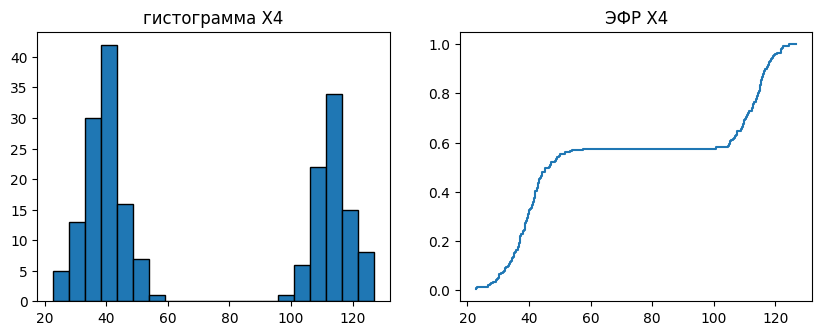

In [8]:
x4 = np.sort(df['X4'].values)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].hist(x4, bins=20, edgecolor='black')
ax[0].set_title('гистограмма X4')
ax[1].step(x4, np.arange(1, n + 1) / n)
ax[1].set_title('ЭФР X4')
plt.show()

X1 ложится на нормальное, X2 на равномерное, X3 на показательное со сдвигом: эмпирическая и параметрическая вероятности расходятся не больше чем на 0.02.

Группировка X1 по десяти интервалам меняет среднее на 0.14%, дисперсию на 0.35%, так что моменты по гистограмме считать можно.

У X4 два горба и ступенька на ЭФР, одним средним такую выборку не описать - оно попадает в провал между группами